# Semana 9: Introduccion a las redes neuronales
## Fundamentos de IA y Machine Learning (92-0025)
### Universidad Latinoamericana de Ciencia y Tecnologia - ULACIT
### III Cuatrimestre 2025

---

**Profesor:** Lic. Jordy Jesus Alfaro Brenes

**Objetivo de la sesion:** Comprender los fundamentos de las redes neuronales artificiales mediante la ejecucion practica de codigo, desde la neurona artificial hasta el entrenamiento completo de un modelo.

**Estructura del notebook:**
1. De la neurona biologica a la neurona artificial
2. Estructura basica: capas, pesos y sesgos
3. Funciones de activacion
4. Forward propagation paso a paso
5. Backpropagation y entrenamiento
6. Caso aplicado completo: prediccion de calidad del vino
7. Recursos interactivos para explorar por su cuenta

> **Nota:** Ejecuten cada celda en orden (Shift + Enter). No se necesita experiencia previa en programacion: el codigo esta comentado y lo importante es entender *que hace*, no *como se escribe*.

---
## 0. Preparacion del entorno
Primero instalamos e importamos las librerias necesarias. Solo deben ejecutar esta celda una vez.

In [2]:
# Librerias necesarias (todas vienen preinstaladas en Colab)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual
PURPLE = '#2D1B4E'
CYAN = '#00D4FF'
LIGHT_PURPLE = '#6B4C9A'
DARK_BG = '#1a1a2e'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Entorno listo. Pueden continuar con la siguiente celda.')

Entorno listo. Pueden continuar con la siguiente celda.


---
## 1. De la neurona biologica a la neurona artificial

El cerebro humano tiene aproximadamente **86 mil millones de neuronas**, cada una conectada a miles de otras, y consume apenas **20 vatios de energia** (menos que una bombilla).

La correspondencia entre la neurona biologica y la artificial es directa:

| Neurona biologica | Neurona artificial | Analogia de negocios |
|---|---|---|
| Dendritas (reciben senales) | Entradas (x1, x2, ...) | La bandeja de entrada de un gerente |
| Fuerza sinaptica | Pesos (w1, w2, ...) | Importancia de cada correo |
| Soma (decide si dispara) | Suma ponderada + Activacion | El cerebro del gerente que pondera |
| Umbral de disparo | Sesgo (bias) | El umbral de urgencia para actuar |
| Axon (transmite la senal) | Salida (output) | El correo que envia con su decision |

Vamos a construir **una sola neurona artificial desde cero** para entender como funciona.

In [1]:
# === UNA NEURONA ARTIFICIAL DESDE CERO ===
# Imaginemos un banco que decide si aprueba un prestamo.
# La neurona recibe 3 entradas:
#   x1 = puntaje crediticio normalizado (0 a 1)
#   x2 = ingreso mensual normalizado (0 a 1)
#   x3 = anos de historial laboral normalizado (0 a 1)

# Entradas del cliente
x1 = 0.8   # Buen puntaje crediticio
x2 = 0.6   # Ingreso moderado
x3 = 0.9   # Largo historial laboral

# Pesos: cuanto importa cada factor para la decision
w1 = 0.5   # El puntaje crediticio es bastante importante
w2 = 0.3   # El ingreso importa, pero menos
w3 = 0.2   # El historial laboral importa un poco

# Sesgo (bias): ajusta el umbral general de aprobacion
b = -0.4   # Negativo = el banco es conservador

# PASO 1: Suma ponderada (como la neurona biologica agrega senales)
z = (x1 * w1) + (x2 * w2) + (x3 * w3) + b

print('=== NEURONA ARTIFICIAL: Aprobacion de prestamo ===')
print(f'\nEntradas del cliente:')
print(f'  Puntaje crediticio (x1): {x1} x peso {w1} = {x1*w1:.2f}')
print(f'  Ingreso mensual   (x2): {x2} x peso {w2} = {x2*w2:.2f}')
print(f'  Historial laboral (x3): {x3} x peso {w3} = {x3*w3:.2f}')
print(f'  Sesgo (bias):                              = {b}')
print(f'  ------------------------------------------------')
print(f'  Suma ponderada (z):                        = {z:.2f}')

# PASO 2: Funcion de activacion (sigmoid -> convierte a probabilidad)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

probabilidad = sigmoid(z)

print(f'\nFuncion de activacion sigmoid(z) = {probabilidad:.4f}')
print(f'\nInterpretacion: hay un {probabilidad*100:.1f}% de probabilidad de aprobacion.')

if probabilidad >= 0.5:
    print('>>> DECISION: Prestamo APROBADO')
else:
    print('>>> DECISION: Prestamo RECHAZADO')

=== NEURONA ARTIFICIAL: Aprobacion de prestamo ===

Entradas del cliente:
  Puntaje crediticio (x1): 0.8 x peso 0.5 = 0.40
  Ingreso mensual   (x2): 0.6 x peso 0.3 = 0.18
  Historial laboral (x3): 0.9 x peso 0.2 = 0.18
  Sesgo (bias):                              = -0.4
  ------------------------------------------------
  Suma ponderada (z):                        = 0.36


NameError: name 'np' is not defined

In [3]:
# === EXPERIMENTO: Cambien los valores y vean que pasa ===
# Modifiquen las entradas y pesos para ver como cambia la decision.

# Prueben estos escenarios:
#   Cliente riesgoso: x1=0.2, x2=0.3, x3=0.1
#   Cliente excelente: x1=0.95, x2=0.9, x3=0.85
#   Banco mas permisivo: cambien b = -0.1
#   Puntaje crediticio mas importante: w1 = 0.8, w2 = 0.1, w3 = 0.1

# MODIFIQUEN AQUI:
x1_nuevo = 0.2
x2_nuevo = 0.3
x3_nuevo = 0.1

z_nuevo = (x1_nuevo * w1) + (x2_nuevo * w2) + (x3_nuevo * w3) + b
prob_nuevo = sigmoid(z_nuevo)

print(f'Nuevo cliente: x1={x1_nuevo}, x2={x2_nuevo}, x3={x3_nuevo}')
print(f'Suma ponderada: {z_nuevo:.2f}')
print(f'Probabilidad de aprobacion: {prob_nuevo*100:.1f}%')
print(f'Decision: {"APROBADO" if prob_nuevo >= 0.5 else "RECHAZADO"}')

Nuevo cliente: x1=0.2, x2=0.3, x3=0.1
Suma ponderada: -0.19
Probabilidad de aprobacion: 45.3%
Decision: RECHAZADO


### Punto clave

Lo que acabamos de hacer manualmente (definir pesos y sesgo) es exactamente lo que hace el **entrenamiento** de una red neuronal de forma automatica: encuentra los mejores valores de pesos y sesgos para que las predicciones sean lo mas precisas posible.

---
## 2. Estructura basica: capas, pesos y sesgos

Una red neuronal tiene tres tipos de capas:
- **Capa de entrada:** recibe los datos (cada neurona = una caracteristica)
- **Capas ocultas:** donde ocurre el "aprendizaje" (extraen patrones cada vez mas abstractos)
- **Capa de salida:** produce la prediccion final

Vamos a visualizar la estructura y el flujo de datos.

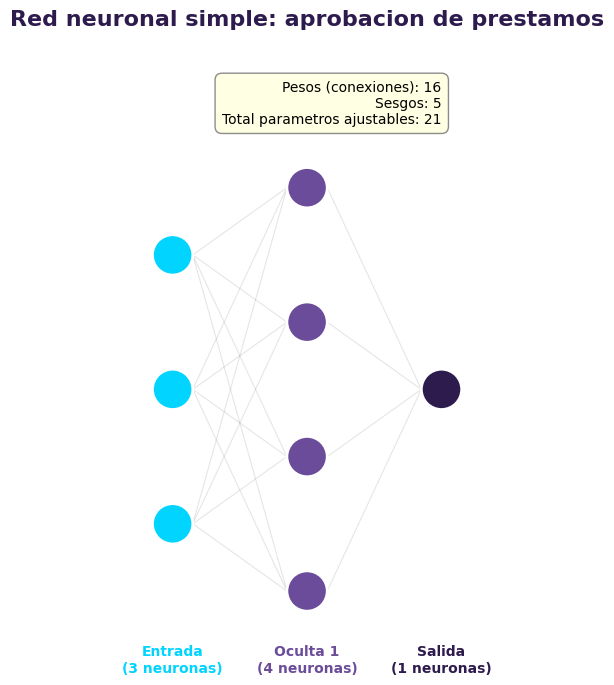

Cada linea gris es un "peso" (conexion) que la red debe aprender.
Con solo 3 entradas y 4 neuronas ocultas, ya tenemos 21 parametros ajustables.
GPT-4 tiene cientos de miles de millones de parametros.


In [4]:
# === VISUALIZACION: Arquitectura de una red neuronal ===

def dibujar_red_neuronal(capas, titulo='Arquitectura de la red neuronal'):
    """Dibuja una red neuronal con las capas especificadas."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.set_xlim(-0.5, len(capas) - 0.5)
    ax.set_ylim(-0.5, max(capas))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo, fontsize=16, fontweight='bold', color=PURPLE, pad=20)

    nombres = ['Entrada'] + [f'Oculta {i+1}' for i in range(len(capas)-2)] + ['Salida']
    colores = [CYAN] + [LIGHT_PURPLE]*(len(capas)-2) + [PURPLE]
    posiciones = []

    for i, n in enumerate(capas):
        capa_pos = []
        offset = (max(capas) - n) / 2
        for j in range(n):
            y = offset + j
            capa_pos.append((i, y))
            circle = plt.Circle((i, y), 0.15, color=colores[i],
                              ec='white', lw=2, zorder=5)
            ax.add_patch(circle)
        posiciones.append(capa_pos)

        ax.text(i, -0.4, f'{nombres[i]}\n({n} neuronas)',
                ha='center', va='top', fontsize=10, fontweight='bold',
                color=colores[i])

    # Dibujar conexiones (pesos)
    for i in range(len(capas)-1):
        for pos1 in posiciones[i]:
            for pos2 in posiciones[i+1]:
                ax.plot([pos1[0]+0.15, pos2[0]-0.15],
                       [pos1[1], pos2[1]],
                       'gray', alpha=0.2, lw=0.8)

    # Contar parametros
    total_pesos = sum(capas[i]*capas[i+1] for i in range(len(capas)-1))
    total_sesgos = sum(capas[i+1] for i in range(len(capas)-1))
    total = total_pesos + total_sesgos

    info = (f'Pesos (conexiones): {total_pesos}\n'
            f'Sesgos: {total_sesgos}\n'
            f'Total parametros ajustables: {total}')
    ax.text(len(capas)-1, max(capas)-0.2, info,
            fontsize=10, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                     edgecolor='gray', alpha=0.9))

    plt.tight_layout()
    plt.show()

# Red para nuestro ejemplo de prestamos: 3 entradas, 4 ocultas, 1 salida
dibujar_red_neuronal([3, 4, 1],
    titulo='Red neuronal simple: aprobacion de prestamos')

print('Cada linea gris es un "peso" (conexion) que la red debe aprender.')
print('Con solo 3 entradas y 4 neuronas ocultas, ya tenemos 21 parametros ajustables.')
print('GPT-4 tiene cientos de miles de millones de parametros.')

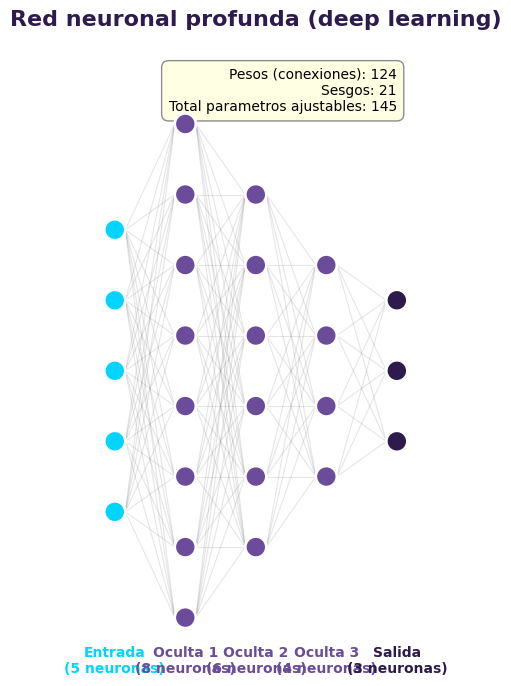

A medida que agregamos capas, la red puede aprender patrones mas complejos.
Pero tambien necesita mas datos y mas tiempo de entrenamiento.


In [5]:
# === Red mas compleja: multiples capas ocultas ===
# Esto es lo que hace "deep" al "deep learning": muchas capas ocultas.

dibujar_red_neuronal([5, 8, 6, 4, 3],
    titulo='Red neuronal profunda (deep learning)')

print('A medida que agregamos capas, la red puede aprender patrones mas complejos.')
print('Pero tambien necesita mas datos y mas tiempo de entrenamiento.')

### Conteo de parametros: por que importa para los negocios

Cada parametro (peso o sesgo) es un numero que la red debe ajustar durante el entrenamiento. Mas parametros significa:
- Mayor capacidad para capturar patrones complejos
- Pero tambien mayor costo computacional (mas GPUs, mas energia, mas dinero)
- Y mayor riesgo de **overfitting** (memorizar datos en vez de aprender patrones)

Por ejemplo, entrenar GPT-4 costo aproximadamente USD 100 millones. DeepSeek-V3, usando arquitectura Mixture of Experts, logro resultados comparables por solo USD 5.5 millones.

---
## 3. Funciones de activacion

Las funciones de activacion son las que le dan a las redes neuronales su poder. Sin ellas, una red de muchas capas seria equivalente a una sola operacion lineal (como una regresion).

Vamos a visualizar las cuatro funciones clasicas.

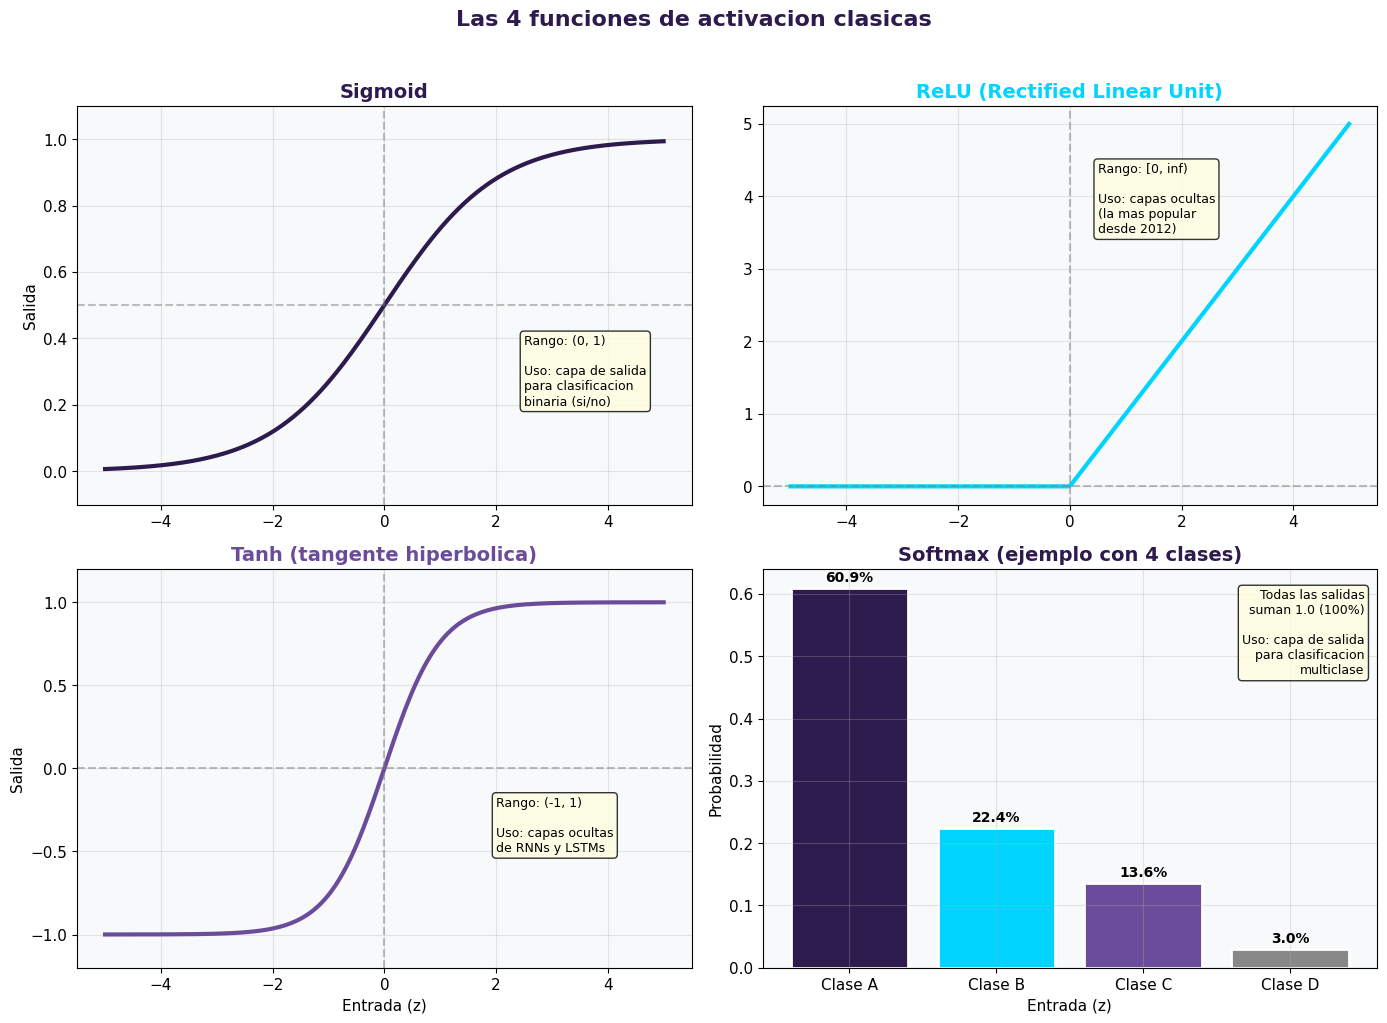

REGLA PRACTICA para elegir funcion de activacion:
  - Capas ocultas -> ReLU (rapida, efectiva, estandar de la industria)
  - Salida binaria (si/no) -> Sigmoid
  - Salida multiclase (A/B/C/D) -> Softmax
  - Predecir un numero (regresion) -> Lineal (sin activacion)


In [6]:
# === VISUALIZACION: Las 4 funciones de activacion clasicas ===

x = np.linspace(-5, 5, 200)

# Definir las funciones
def relu(x):
    return np.maximum(0, x)

def tanh_func(x):
    return np.tanh(x)

def softmax_demo(x):
    """Softmax aplicada a un vector (se vera en la siguiente celda)"""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Las 4 funciones de activacion clasicas',
             fontsize=16, fontweight='bold', color=PURPLE, y=1.02)

# --- SIGMOID ---
ax = axes[0, 0]
ax.plot(x, sigmoid(x), color=PURPLE, lw=3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Sigmoid', fontsize=14, fontweight='bold', color=PURPLE)
ax.set_ylabel('Salida')
ax.text(2.5, 0.2, 'Rango: (0, 1)\n\nUso: capa de salida\npara clasificacion\nbinaria (si/no)',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_ylim(-0.1, 1.1)

# --- ReLU ---
ax = axes[0, 1]
ax.plot(x, relu(x), color=CYAN, lw=3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('ReLU (Rectified Linear Unit)', fontsize=14, fontweight='bold', color=CYAN)
ax.text(0.5, 3.5, 'Rango: [0, inf)\n\nUso: capas ocultas\n(la mas popular\ndesde 2012)',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Tanh ---
ax = axes[1, 0]
ax.plot(x, tanh_func(x), color=LIGHT_PURPLE, lw=3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Tanh (tangente hiperbolica)', fontsize=14, fontweight='bold', color=LIGHT_PURPLE)
ax.set_xlabel('Entrada (z)')
ax.set_ylabel('Salida')
ax.text(2.0, -0.5, 'Rango: (-1, 1)\n\nUso: capas ocultas\nde RNNs y LSTMs',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_ylim(-1.2, 1.2)

# --- Softmax (ejemplo con barras) ---
ax = axes[1, 1]
logits = np.array([2.0, 1.0, 0.5, -1.0])
probs = softmax_demo(logits)
categorias = ['Clase A', 'Clase B', 'Clase C', 'Clase D']
colores_bar = [PURPLE, CYAN, LIGHT_PURPLE, '#888888']
bars = ax.bar(categorias, probs, color=colores_bar, edgecolor='white', lw=2)
ax.set_title('Softmax (ejemplo con 4 clases)', fontsize=14, fontweight='bold', color=PURPLE)
ax.set_xlabel('Entrada (z)')
ax.set_ylabel('Probabilidad')
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.1%}', ha='center', fontsize=10, fontweight='bold')
ax.text(0.98, 0.95, 'Todas las salidas\nsuman 1.0 (100%)\n\nUso: capa de salida\npara clasificacion\nmulticlase',
        fontsize=9, transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print('REGLA PRACTICA para elegir funcion de activacion:')
print('  - Capas ocultas -> ReLU (rapida, efectiva, estandar de la industria)')
print('  - Salida binaria (si/no) -> Sigmoid')
print('  - Salida multiclase (A/B/C/D) -> Softmax')
print('  - Predecir un numero (regresion) -> Lineal (sin activacion)')

In [7]:
# === EXPERIMENTO INTERACTIVO: El efecto de la funcion de activacion ===
# Veamos como la misma entrada produce salidas diferentes segun la activacion.

z_ejemplo = np.array([-3, -1, 0, 0.5, 2, 4])

print('Entrada z:  ', z_ejemplo)
print('-' * 60)
print(f'{"Sigmoid:":12s}', [f'{sigmoid(v):.3f}' for v in z_ejemplo])
print(f'{"ReLU:":12s}', [f'{relu(v):.3f}' for v in z_ejemplo])
print(f'{"Tanh:":12s}', [f'{tanh_func(v):.3f}' for v in z_ejemplo])
print()
print('Observen:')
print('  - Sigmoid comprime todo entre 0 y 1 (util para probabilidades)')
print('  - ReLU elimina los negativos (crea representaciones "dispersas")')
print('  - Tanh es como sigmoid pero centrada en 0 (rango -1 a 1)')

Entrada z:   [-3.  -1.   0.   0.5  2.   4. ]
------------------------------------------------------------
Sigmoid:     ['0.047', '0.269', '0.500', '0.622', '0.881', '0.982']
ReLU:        ['0.000', '0.000', '0.000', '0.500', '2.000', '4.000']
Tanh:        ['-0.995', '-0.762', '0.000', '0.462', '0.964', '0.999']

Observen:
  - Sigmoid comprime todo entre 0 y 1 (util para probabilidades)
  - ReLU elimina los negativos (crea representaciones "dispersas")
  - Tanh es como sigmoid pero centrada en 0 (rango -1 a 1)


### Funciones modernas (bonus cultural)

En 2025-2026, los modelos mas avanzados (como LLaMA, DeepSeek, Gemma) usan funciones mas sofisticadas como **SwiGLU** y **GEGLU**, que combinan mecanismos de compuerta con activaciones suaves. La idea es la misma: introducir no-linealidad, pero de forma mas eficiente para redes muy profundas.

---
## 4. Forward propagation paso a paso

El forward propagation ("propagacion hacia adelante") es el proceso de pasar datos a traves de toda la red para obtener una prediccion. Es como una cadena de analistas: cada uno recibe informacion, la procesa y la pasa al siguiente.

Vamos a verlo en accion con una red pequena.

In [8]:
# === FORWARD PROPAGATION: Paso a paso con numeros reales ===
# Red: 2 entradas -> 3 neuronas ocultas (ReLU) -> 1 salida (sigmoid)

np.random.seed(42)  # Para reproducibilidad

# Datos de entrada (un cliente)
X = np.array([0.7, 0.3])  # [puntaje crediticio, ratio deuda/ingreso]

# Pesos y sesgos de la capa oculta (normalmente se inicializan aleatorios)
W1 = np.array([[0.4, -0.2, 0.5],
               [0.3,  0.6, -0.1]])  # 2 entradas x 3 neuronas = 6 pesos
b1 = np.array([0.1, -0.1, 0.2])     # 3 sesgos (uno por neurona oculta)

# Pesos y sesgos de la capa de salida
W2 = np.array([[0.7], [-0.3], [0.5]])  # 3 neuronas ocultas x 1 salida = 3 pesos
b2 = np.array([-0.2])                   # 1 sesgo

print('=' * 65)
print('FORWARD PROPAGATION: paso a paso')
print('=' * 65)
print(f'\n--- CAPA DE ENTRADA ---')
print(f'  X = {X}  (puntaje crediticio=0.7, ratio deuda/ingreso=0.3)')

# Paso 1: Capa oculta
print(f'\n--- CAPA OCULTA (3 neuronas con ReLU) ---')
z1 = np.dot(X, W1) + b1  # Suma ponderada
print(f'  Suma ponderada (z1): {z1}')

# Detalle neurona por neurona:
for i in range(3):
    calculo = f'({X[0]}*{W1[0,i]}) + ({X[1]}*{W1[1,i]}) + {b1[i]}'
    print(f'    Neurona {i+1}: {calculo} = {z1[i]:.2f}')

a1 = relu(z1)  # Activacion ReLU
print(f'  Despues de ReLU (a1):  {a1}')
print(f'    (los valores negativos se convierten en 0)')

# Paso 2: Capa de salida
print(f'\n--- CAPA DE SALIDA (1 neurona con Sigmoid) ---')
z2 = np.dot(a1, W2) + b2
print(f'  Suma ponderada (z2): {z2[0]:.4f}')
a2 = sigmoid(z2)
print(f'  Despues de Sigmoid:  {a2[0]:.4f}')

print(f'\n{"=" * 65}')
print(f'PREDICCION FINAL: {a2[0]:.4f} ({a2[0]*100:.1f}% probabilidad de aprobacion)')
print(f'DECISION: {"APROBADO" if a2[0] >= 0.5 else "RECHAZADO"}')
print(f'{"=" * 65}')

FORWARD PROPAGATION: paso a paso

--- CAPA DE ENTRADA ---
  X = [0.7 0.3]  (puntaje crediticio=0.7, ratio deuda/ingreso=0.3)

--- CAPA OCULTA (3 neuronas con ReLU) ---
  Suma ponderada (z1): [ 0.47 -0.06  0.52]
    Neurona 1: (0.7*0.4) + (0.3*0.3) + 0.1 = 0.47
    Neurona 2: (0.7*-0.2) + (0.3*0.6) + -0.1 = -0.06
    Neurona 3: (0.7*0.5) + (0.3*-0.1) + 0.2 = 0.52
  Despues de ReLU (a1):  [0.47 0.   0.52]
    (los valores negativos se convierten en 0)

--- CAPA DE SALIDA (1 neurona con Sigmoid) ---
  Suma ponderada (z2): 0.3890
  Despues de Sigmoid:  0.5960

PREDICCION FINAL: 0.5960 (59.6% probabilidad de aprobacion)
DECISION: APROBADO


### Punto clave del forward propagation

Lo que acabamos de hacer es **una sola pasada** por la red con pesos inventados. El resultado no es bueno porque los pesos no se han entrenado.

Para que la red aprenda, necesitamos:
1. Medir **cuanto se equivoco** (funcion de perdida)
2. Calcular **que pesos ajustar y en que direccion** (backpropagation)
3. **Actualizar los pesos** (optimizador)
4. Repetir miles de veces

---
## 5. Backpropagation y entrenamiento

### La funcion de perdida: midiendo el error

Antes de corregir los pesos, necesitamos medir *cuanto se equivoco la red*.

=== FUNCION DE PERDIDA: Entropia cruzada binaria ===

La red predijo: 0.3 (30% probabilidad de aprobar)
Valor real:     1.0 (si debia aprobarse)
Perdida:        1.2040 (mientras mas alto, peor)

Si hubiera predicho 0.9 (90%), la perdida seria: 0.1054
Reduccion de error: 91%


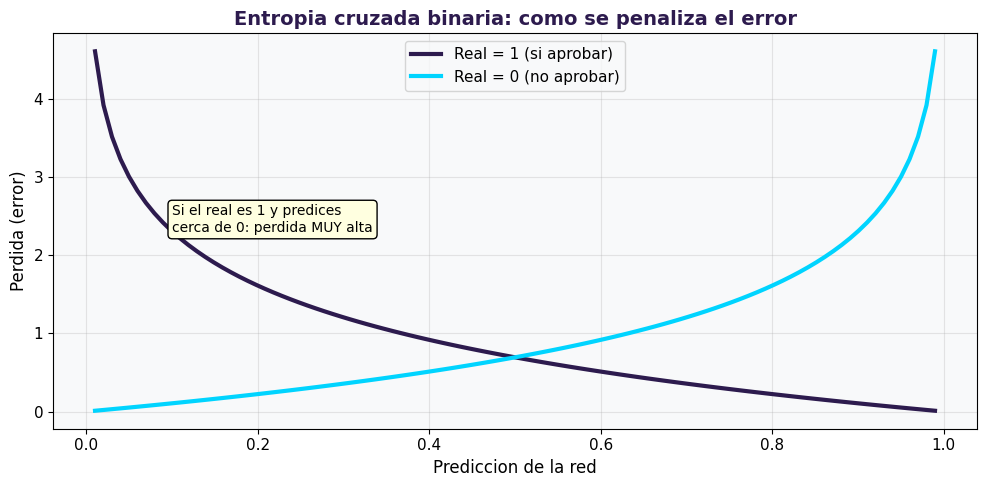

In [10]:
# === FUNCIONES DE PERDIDA ===

# --- Para clasificacion: Entropia Cruzada Binaria ---
def binary_cross_entropy(y_pred, y_real):
    epsilon = 1e-15  # Evitar log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred))

# Ejemplo: la red predijo 0.3, pero la respuesta correcta era 1 (si aprobar)
prediccion = 0.3
real = 1.0
perdida = binary_cross_entropy(prediccion, real)

print('=== FUNCION DE PERDIDA: Entropia cruzada binaria ===')
print(f'\nLa red predijo: {prediccion} (30% probabilidad de aprobar)')
print(f'Valor real:     {real} (si debia aprobarse)')
print(f'Perdida:        {perdida:.4f} (mientras mas alto, peor)')

# Comparar con una prediccion mejor
prediccion_buena = 0.9
perdida_buena = binary_cross_entropy(prediccion_buena, real)
print(f'\nSi hubiera predicho {prediccion_buena} (90%), la perdida seria: {perdida_buena:.4f}')
print(f'Reduccion de error: {((perdida - perdida_buena)/perdida)*100:.0f}%')

# Visualizar
preds = np.linspace(0.01, 0.99, 100)
perdidas_1 = [binary_cross_entropy(p, 1.0) for p in preds]  # Real = 1
perdidas_0 = [binary_cross_entropy(p, 0.0) for p in preds]  # Real = 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(preds, perdidas_1, color=PURPLE, lw=3, label='Real = 1 (si aprobar)')
ax.plot(preds, perdidas_0, color=CYAN, lw=3, label='Real = 0 (no aprobar)')
ax.set_xlabel('Prediccion de la red', fontsize=12)
ax.set_ylabel('Perdida (error)', fontsize=12)
ax.set_title('Entropia cruzada binaria: como se penaliza el error',
             fontsize=14, fontweight='bold', color=PURPLE)
ax.legend(fontsize=11)
ax.annotate('Si el real es 1 y predices\ncerca de 0: perdida MUY alta',
            xy=(0.1, 2.3), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
plt.tight_layout()
plt.show()

=== ENTRENAMIENTO: Ajuste iterativo de un peso ===
Objetivo: que la neurona prediga 1.0 cuando la entrada es 1.5
Peso inicial: -1.0 (muy malo)

Iteracion  1: peso=-1.0000 -> pred=0.1824 -> perdida=1.7014 -> gradiente=-1.2264 -> nuevo peso=-0.3868
Iteracion  2: peso=-0.3868 -> pred=0.3589 -> perdida=1.0248 -> gradiente=-0.9617 -> nuevo peso=+0.0940
Iteracion  3: peso=+0.0940 -> pred=0.5352 -> perdida=0.6251 -> gradiente=-0.6972 -> nuevo peso=+0.4426
Iteracion  4: peso=+0.4426 -> pred=0.6601 -> perdida=0.4153 -> gradiente=-0.5098 -> nuevo peso=+0.6975
Iteracion  5: peso=+0.6975 -> pred=0.7401 -> perdida=0.3010 -> gradiente=-0.3899 -> nuevo peso=+0.8925
  ...
Iteracion 10: peso=+1.3818 -> pred=0.8882 -> perdida=0.1185 -> gradiente=-0.1677 -> nuevo peso=+1.4656

Resultado final: peso=1.4656, prediccion=0.9001 (objetivo: 1.0)


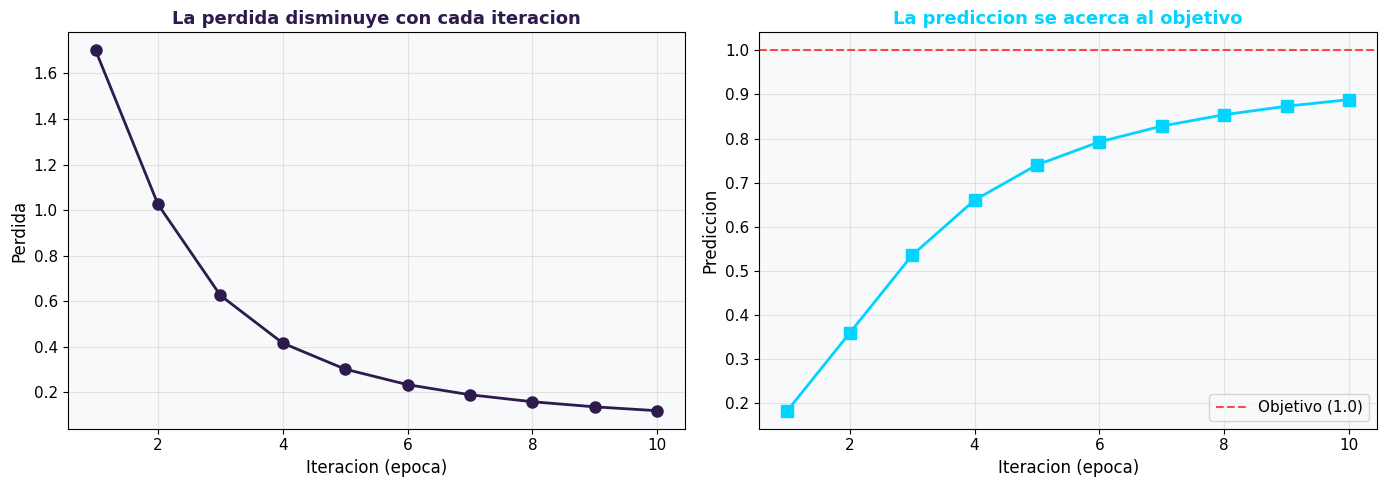


Esto es exactamente lo que hace backpropagation + gradient descent:
  1. Forward pass: calcula prediccion
  2. Calcula la perdida (cuanto se equivoco)
  3. Backpropagation: calcula el gradiente (direccion de mejora)
  4. Actualiza los pesos un poquito en esa direccion
  5. Repite hasta que la perdida sea minima


In [11]:
# === BACKPROPAGATION + GRADIENT DESCENT: Simulacion visual ===
# Vamos a ver como un solo peso se ajusta iterativamente para reducir la perdida.

# Simulacion simplificada: una neurona, un peso, intentando aprender y=1
# cuando x=1.5

x_fijo = 1.5
y_real = 1.0
learning_rate = 0.5

# Empezamos con un peso aleatorio
w = -1.0  # Peso inicial (malo)

historial_w = [w]
historial_loss = []
historial_pred = []

print('=== ENTRENAMIENTO: Ajuste iterativo de un peso ===')
print(f'Objetivo: que la neurona prediga {y_real} cuando la entrada es {x_fijo}')
print(f'Peso inicial: {w} (muy malo)\n')

for epoch in range(10):
    # Forward pass
    z = x_fijo * w
    pred = sigmoid(z)
    loss = binary_cross_entropy(pred, y_real)

    # Backpropagation: calcular gradiente (derivada de la perdida respecto al peso)
    # dL/dw = (pred - y_real) * x
    gradiente = (pred - y_real) * x_fijo

    # Actualizar peso (gradient descent)
    w_anterior = w
    w = w - learning_rate * gradiente

    historial_w.append(w)
    historial_loss.append(loss)
    historial_pred.append(pred)

    if epoch < 5 or epoch == 9:
        print(f'Iteracion {epoch+1:2d}: peso={w_anterior:+.4f} -> pred={pred:.4f} '
              f'-> perdida={loss:.4f} -> gradiente={gradiente:+.4f} -> nuevo peso={w:+.4f}')
    elif epoch == 5:
        print('  ...')

print(f'\nResultado final: peso={w:.4f}, prediccion={sigmoid(x_fijo*w):.4f} (objetivo: 1.0)')

# Visualizar el proceso
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, 11), historial_loss, 'o-', color=PURPLE, lw=2, markersize=8)
ax1.set_xlabel('Iteracion (epoca)', fontsize=12)
ax1.set_ylabel('Perdida', fontsize=12)
ax1.set_title('La perdida disminuye con cada iteracion',
              fontsize=13, fontweight='bold', color=PURPLE)

ax2.plot(range(1, 11), historial_pred, 's-', color=CYAN, lw=2, markersize=8)
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Objetivo (1.0)')
ax2.set_xlabel('Iteracion (epoca)', fontsize=12)
ax2.set_ylabel('Prediccion', fontsize=12)
ax2.set_title('La prediccion se acerca al objetivo',
              fontsize=13, fontweight='bold', color=CYAN)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print('\nEsto es exactamente lo que hace backpropagation + gradient descent:')
print('  1. Forward pass: calcula prediccion')
print('  2. Calcula la perdida (cuanto se equivoco)')
print('  3. Backpropagation: calcula el gradiente (direccion de mejora)')
print('  4. Actualiza los pesos un poquito en esa direccion')
print('  5. Repite hasta que la perdida sea minima')

### Analogia de negocios para backpropagation

Imaginen un lanzamiento de producto que fallo en ventas:

1. **Forward propagation** = El equipo toma decisiones (diseno, precio, marketing) y lanza el producto
2. **Funcion de perdida** = Se mide el resultado: "vendimos 40% menos de lo esperado"
3. **Backpropagation** = Analisis post-mortem: "el precio fue el factor que mas afecto (-60% de impacto), luego el marketing (-25%), luego el diseno (-15%)"
4. **Gradient descent** = Se ajustan las decisiones proporcionalmente: se baja mas el precio que lo que se cambia el diseno
5. Se repite para el proximo lanzamiento, cada vez con mejores decisiones

---
## 6. Caso aplicado completo: prediccion de calidad del vino

Ahora vamos a juntar todo y entrenar una red neuronal real usando el **Wine Dataset** de scikit-learn. Este dataset contiene mediciones quimicas de vinos de tres cultivares italianos, y la tarea es clasificar de que cultivar proviene cada vino.

Esto es analogo a un negocio de importacion de vinos que quiere automatizar la verificacion de origen.

In [12]:
# === CASO APLICADO: Clasificacion de vinos con red neuronal ===

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Cargar datos
wine = load_wine()
X = wine.data
y = wine.target
nombres_features = wine.feature_names
nombres_clases = wine.target_names

# Explorar los datos
df = pd.DataFrame(X, columns=nombres_features)
df['cultivar'] = [nombres_clases[i] for i in y]

print('=== DATASET: Vinos italianos ===')
print(f'Total de muestras: {len(X)}')
print(f'Caracteristicas (entradas): {len(nombres_features)}')
print(f'Clases (salidas): {list(nombres_clases)}')
print(f'\nDistribucion por clase:')
for i, nombre in enumerate(nombres_clases):
    print(f'  {nombre}: {(y == i).sum()} muestras')

print(f'\nPrimeras 5 filas:')
df.head()

=== DATASET: Vinos italianos ===
Total de muestras: 178
Caracteristicas (entradas): 13
Clases (salidas): [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Distribucion por clase:
  class_0: 59 muestras
  class_1: 71 muestras
  class_2: 48 muestras

Primeras 5 filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [13]:
# === PASO 1: Preparar los datos ===
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar los datos (MUY importante para redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('=== PREPARACION DE DATOS ===')
print(f'Datos de entrenamiento: {X_train_scaled.shape[0]} muestras')
print(f'Datos de prueba:        {X_test_scaled.shape[0]} muestras')
print(f'\nPor que escalar? Las redes neuronales funcionan mejor cuando')
print(f'todas las caracteristicas estan en un rango similar.')
print(f'\nAntes de escalar - alcohol: media={X_train[:, 0].mean():.1f}, std={X_train[:, 0].std():.1f}')
print(f'Despues de escalar - alcohol: media={X_train_scaled[:, 0].mean():.4f}, std={X_train_scaled[:, 0].std():.4f}')

=== PREPARACION DE DATOS ===
Datos de entrenamiento: 142 muestras
Datos de prueba:        36 muestras

Por que escalar? Las redes neuronales funcionan mejor cuando
todas las caracteristicas estan en un rango similar.

Antes de escalar - alcohol: media=13.0, std=0.8
Despues de escalar - alcohol: media=0.0000, std=1.0000


In [14]:
# === PASO 2: Crear y entrenar la red neuronal ===

# Arquitectura: 13 entradas -> 16 neuronas ocultas -> 8 neuronas ocultas -> 3 salidas
red_neuronal = MLPClassifier(
    hidden_layer_sizes=(16, 8),  # 2 capas ocultas: 16 y 8 neuronas
    activation='relu',            # Funcion de activacion: ReLU en capas ocultas
    solver='adam',                # Optimizador: Adam (el mas popular)
    max_iter=500,                 # Maximo de iteraciones de entrenamiento
    random_state=42,
    verbose=False
)

print('=== ARQUITECTURA DE LA RED ===')
print(f'Capa de entrada:  {X_train_scaled.shape[1]} neuronas (13 caracteristicas quimicas)')
print(f'Capa oculta 1:    16 neuronas con activacion ReLU')
print(f'Capa oculta 2:    8 neuronas con activacion ReLU')
print(f'Capa de salida:   3 neuronas con activacion Softmax (3 cultivares)')
print(f'Optimizador:      Adam')

# Entrenar
print(f'\nEntrenando...')
red_neuronal.fit(X_train_scaled, y_train)
print(f'Entrenamiento completado en {red_neuronal.n_iter_} iteraciones.')

# Contar parametros
total_params = sum(
    w.size for w in red_neuronal.coefs_
) + sum(
    b.size for b in red_neuronal.intercepts_
)
print(f'Total de parametros ajustados: {total_params}')

=== ARQUITECTURA DE LA RED ===
Capa de entrada:  13 neuronas (13 caracteristicas quimicas)
Capa oculta 1:    16 neuronas con activacion ReLU
Capa oculta 2:    8 neuronas con activacion ReLU
Capa de salida:   3 neuronas con activacion Softmax (3 cultivares)
Optimizador:      Adam

Entrenando...
Entrenamiento completado en 421 iteraciones.
Total de parametros ajustados: 387


=== RESULTADOS ===

Precision general (accuracy): 94.4%

Reporte detallado por clase:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



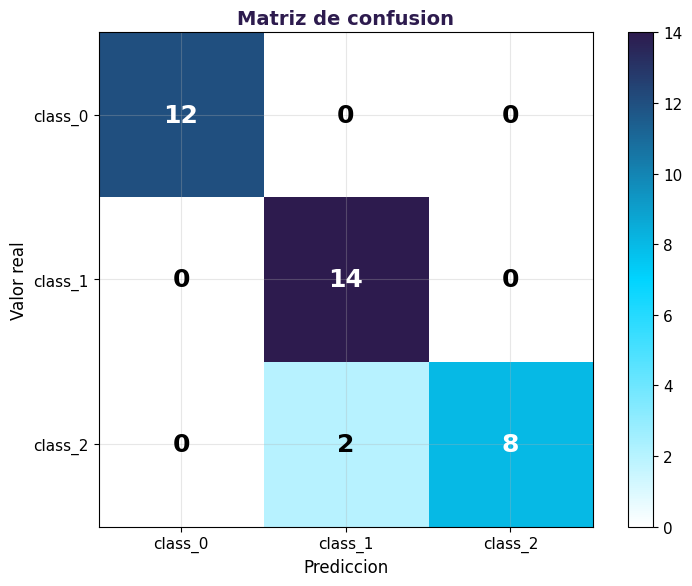

La diagonal muestra las predicciones correctas.
Los valores fuera de la diagonal son errores.


In [15]:
# === PASO 3: Evaluar resultados ===

y_pred = red_neuronal.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print('=== RESULTADOS ===')
print(f'\nPrecision general (accuracy): {accuracy*100:.1f}%')
print(f'\nReporte detallado por clase:')
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
cmap = LinearSegmentedColormap.from_list('ulacit', ['white', CYAN, PURPLE])
im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
ax.set_title('Matriz de confusion', fontsize=14, fontweight='bold', color=PURPLE)

# Anotaciones
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold', color=color)

ax.set_xlabel('Prediccion', fontsize=12)
ax.set_ylabel('Valor real', fontsize=12)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(nombres_clases)
ax.set_yticklabels(nombres_clases)
plt.colorbar(im)
plt.tight_layout()
plt.show()

print('La diagonal muestra las predicciones correctas.')
print('Los valores fuera de la diagonal son errores.')

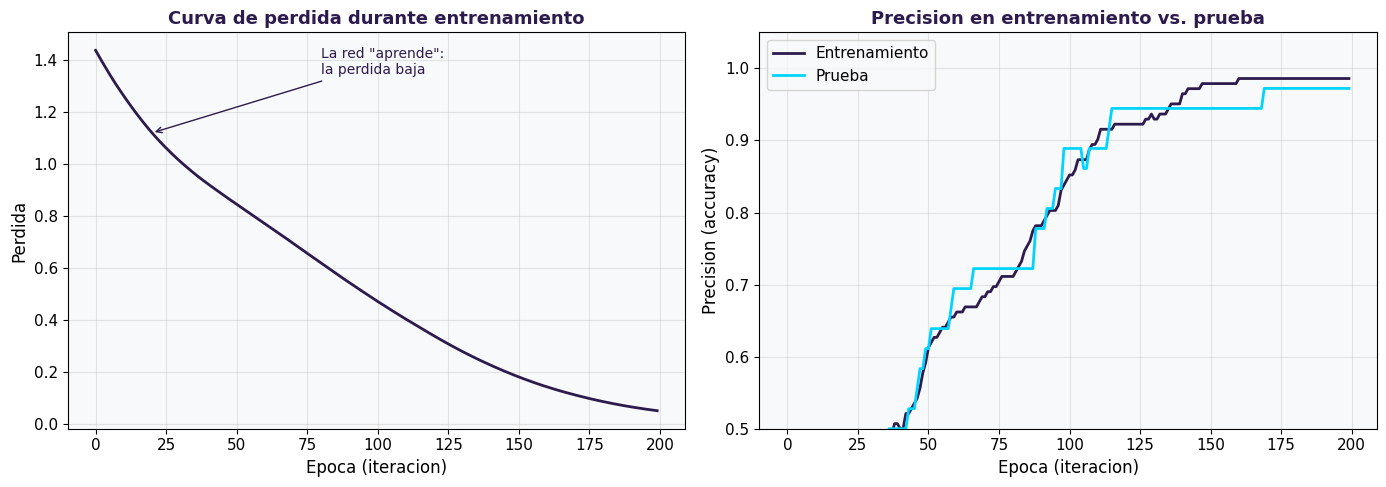

Observen como la perdida baja rapidamente al inicio y luego se estabiliza.
Si la precision de entrenamiento sube mucho pero la de prueba baja,
tenemos OVERFITTING (la red memoriza en vez de aprender).


In [16]:
# === PASO 4: Visualizar la curva de aprendizaje ===
# Reentrenamos guardando el historial de perdida

red_con_historial = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1,       # Una iteracion a la vez
    warm_start=True,  # Continuar entrenamiento
    random_state=42
)

perdidas = []
accuracies_train = []
accuracies_test = []

for i in range(200):
    red_con_historial.fit(X_train_scaled, y_train)
    perdidas.append(red_con_historial.loss_)
    acc_train = accuracy_score(y_train, red_con_historial.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, red_con_historial.predict(X_test_scaled))
    accuracies_train.append(acc_train)
    accuracies_test.append(acc_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(perdidas, color=PURPLE, lw=2)
ax1.set_xlabel('Epoca (iteracion)', fontsize=12)
ax1.set_ylabel('Perdida', fontsize=12)
ax1.set_title('Curva de perdida durante entrenamiento',
              fontsize=13, fontweight='bold', color=PURPLE)
ax1.annotate('La red "aprende":\nla perdida baja', xy=(20, perdidas[20]),
            xytext=(80, perdidas[5]),
            arrowprops=dict(arrowstyle='->', color=PURPLE),
            fontsize=10, color=PURPLE)

ax2.plot(accuracies_train, color=PURPLE, lw=2, label='Entrenamiento')
ax2.plot(accuracies_test, color=CYAN, lw=2, label='Prueba')
ax2.set_xlabel('Epoca (iteracion)', fontsize=12)
ax2.set_ylabel('Precision (accuracy)', fontsize=12)
ax2.set_title('Precision en entrenamiento vs. prueba',
              fontsize=13, fontweight='bold', color=PURPLE)
ax2.legend(fontsize=11)
ax2.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

print('Observen como la perdida baja rapidamente al inicio y luego se estabiliza.')
print('Si la precision de entrenamiento sube mucho pero la de prueba baja,')
print('tenemos OVERFITTING (la red memoriza en vez de aprender).')

In [17]:
# === PASO 5: Experimentar con la arquitectura ===
# Comparemos diferentes configuraciones de red

configuraciones = [
    {'nombre': 'Red minima (4)', 'capas': (4,)},
    {'nombre': 'Red simple (16)', 'capas': (16,)},
    {'nombre': 'Red doble (16, 8)', 'capas': (16, 8)},
    {'nombre': 'Red profunda (32, 16, 8)', 'capas': (32, 16, 8)},
    {'nombre': 'Red muy grande (64, 32, 16)', 'capas': (64, 32, 16)},
]

print('=== COMPARACION DE ARQUITECTURAS ===')
print(f'{"Arquitectura":<30s} {"Parametros":>12s} {"Precision":>10s}')
print('-' * 55)

resultados = []
for config in configuraciones:
    mlp = MLPClassifier(
        hidden_layer_sizes=config['capas'],
        activation='relu', solver='adam',
        max_iter=500, random_state=42
    )
    mlp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test_scaled))
    n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
    print(f'{config["nombre"]:<30s} {n_params:>12,d} {acc:>9.1%}')
    resultados.append({'nombre': config['nombre'], 'params': n_params, 'acc': acc})

print(f'\nLeccion de negocios: mas parametros NO siempre significa mejor resultado.')
print(f'Hay un punto optimo entre complejidad y rendimiento.')
print(f'En la practica, esto se traduce en costo computacional vs. beneficio.')

=== COMPARACION DE ARQUITECTURAS ===
Arquitectura                     Parametros  Precision
-------------------------------------------------------
Red minima (4)                           71     91.7%
Red simple (16)                         275     94.4%
Red doble (16, 8)                       387     94.4%
Red profunda (32, 16, 8)              1,139    100.0%
Red muy grande (64, 32, 16)           3,555     97.2%

Leccion de negocios: mas parametros NO siempre significa mejor resultado.
Hay un punto optimo entre complejidad y rendimiento.
En la practica, esto se traduce en costo computacional vs. beneficio.


In [18]:
# === PASO 6: Hacer predicciones con datos nuevos ===
# Simulemos que llega un vino nuevo al laboratorio

# Tomemos un ejemplo del conjunto de prueba como si fuera "nuevo"
indice = 5
vino_nuevo = X_test[indice:indice+1]
vino_nuevo_scaled = scaler.transform(vino_nuevo)

# Obtener probabilidades por clase
probabilidades = red_neuronal.predict_proba(vino_nuevo_scaled)[0]
prediccion = red_neuronal.predict(vino_nuevo_scaled)[0]

print('=== PREDICCION PARA UN VINO NUEVO ===')
print(f'\nCaracteristicas medidas en laboratorio:')
for nombre, valor in zip(nombres_features[:5], vino_nuevo[0][:5]):
    print(f'  {nombre}: {valor:.2f}')
print(f'  ... y {len(nombres_features)-5} caracteristicas mas')

print(f'\nProbabilidades calculadas por la red (softmax):')
for nombre, prob in zip(nombres_clases, probabilidades):
    barra = '#' * int(prob * 40)
    print(f'  {nombre:>8s}: {prob:.1%} {barra}')

print(f'\nClasificacion: {nombres_clases[prediccion]}')
print(f'Clase real:    {nombres_clases[y_test[indice]]}')
print(f'Resultado:     {"CORRECTO" if prediccion == y_test[indice] else "INCORRECTO"}')

=== PREDICCION PARA UN VINO NUEVO ===

Caracteristicas medidas en laboratorio:
  alcohol: 13.83
  malic_acid: 1.65
  ash: 2.60
  alcalinity_of_ash: 17.20
  magnesium: 94.00
  ... y 8 caracteristicas mas

Probabilidades calculadas por la red (softmax):
   class_0: 99.9% #######################################
   class_1: 0.1% 
   class_2: 0.0% 

Clasificacion: class_0
Clase real:    class_0
Resultado:     CORRECTO


### Resumen del flujo completo

Lo que acabamos de hacer sigue exactamente el ciclo de vida de un proyecto de ML:

1. **Recopilar datos** (el Wine Dataset con 178 muestras)
2. **Preparar datos** (dividir train/test, escalar)
3. **Definir arquitectura** (capas, neuronas, activaciones)
4. **Entrenar** (forward + backpropagation + Adam, 200 iteraciones)
5. **Evaluar** (accuracy, matriz de confusion)
6. **Desplegar** (usar el modelo para nuevas predicciones)

---
## 7. Recursos interactivos para explorar por su cuenta

Les recomiendo estos simuladores web gratuitos (no requieren codigo):

| Herramienta | URL | Que pueden hacer |
|---|---|---|
| TensorFlow Playground | playground.tensorflow.org | Ajustar capas, neuronas y activaciones, ver fronteras de decision en tiempo real |
| Google Teachable Machine | teachablemachine.withgoogle.com | Entrenar un clasificador de imagenes con su webcam en minutos |
| CNN Explainer | poloclub.github.io/cnn-explainer/ | Ver capa por capa como una CNN clasifica imagenes |
| Visualizacion 3D (Harley) | adamharley.com/nn_vis/ | Dibujar digitos y ver la red neuronal procesarlos en 3D |
| 3Blue1Brown (videos) | 3blue1brown.com/topics/neural-networks | Videos animados explicando redes neuronales y backpropagation |

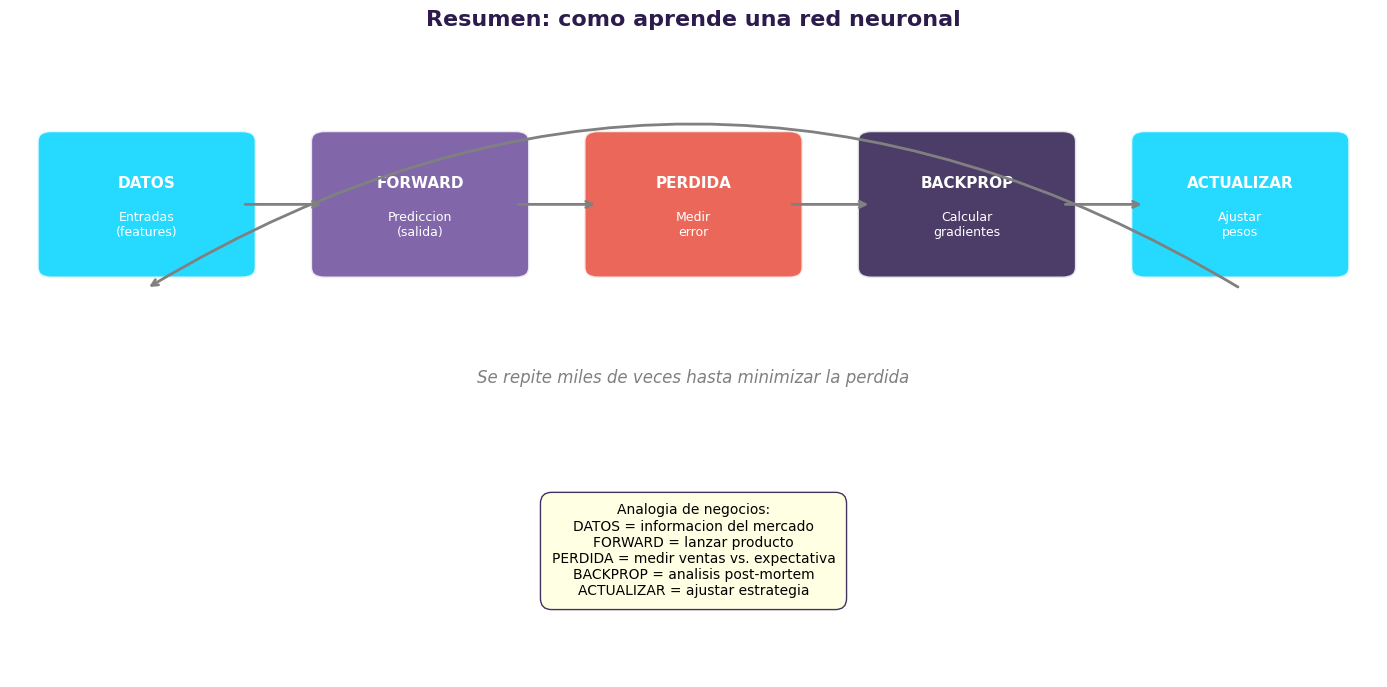


Este es el proceso que ocurre dentro de MLPClassifier.fit()
y dentro de cualquier red neuronal: desde la mas simple hasta GPT-4.


In [19]:
# === DIAGRAMA RESUMEN FINAL ===

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Resumen: como aprende una red neuronal',
             fontsize=16, fontweight='bold', color=PURPLE, pad=15)

pasos = [
    (1, 4.5, 'DATOS', 'Entradas\n(features)', CYAN),
    (3, 4.5, 'FORWARD', 'Prediccion\n(salida)', LIGHT_PURPLE),
    (5, 4.5, 'PERDIDA', 'Medir\nerror', '#e74c3c'),
    (7, 4.5, 'BACKPROP', 'Calcular\ngradientes', PURPLE),
    (9, 4.5, 'ACTUALIZAR', 'Ajustar\npesos', CYAN),
]

for x, y, titulo, detalle, color in pasos:
    rect = mpatches.FancyBboxPatch((x-0.7, y-0.6), 1.4, 1.2,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, edgecolor='white',
                                   alpha=0.85, lw=2)
    ax.add_patch(rect)
    ax.text(x, y+0.2, titulo, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(x, y-0.2, detalle, ha='center', va='center',
            fontsize=9, color='white')

# Flechas
for i in range(4):
    x1 = pasos[i][0] + 0.7
    x2 = pasos[i+1][0] - 0.7
    ax.annotate('', xy=(x2, 4.5), xytext=(x1, 4.5),
               arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Flecha de ciclo
ax.annotate('', xy=(1, 3.7), xytext=(9, 3.7),
           arrowprops=dict(arrowstyle='->', color='gray', lw=2,
                          connectionstyle='arc3,rad=0.3'))
ax.text(5, 2.8, 'Se repite miles de veces hasta minimizar la perdida',
        ha='center', fontsize=12, fontstyle='italic', color='gray')

# Analogia de negocios
analogia = ('Analogia de negocios:\n'
            'DATOS = informacion del mercado\n'
            'FORWARD = lanzar producto\n'
            'PERDIDA = medir ventas vs. expectativa\n'
            'BACKPROP = analisis post-mortem\n'
            'ACTUALIZAR = ajustar estrategia')
ax.text(5, 1.2, analogia, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow',
                 edgecolor=PURPLE, alpha=0.9))

plt.tight_layout()
plt.show()

print('\nEste es el proceso que ocurre dentro de MLPClassifier.fit()')
print('y dentro de cualquier red neuronal: desde la mas simple hasta GPT-4.')

---
## Conceptos clave de esta sesion

1. **Neurona artificial:** recibe entradas ponderadas, las suma, agrega un sesgo y aplica una funcion de activacion. Es la unidad basica de toda red neuronal.

2. **Capas:** entrada (datos), ocultas (aprendizaje), salida (prediccion). Mas capas = mas capacidad para patrones complejos.

3. **Pesos y sesgos:** los parametros que la red ajusta durante el entrenamiento. Son el "conocimiento" de la red.

4. **Funciones de activacion:** introducen no-linealidad. ReLU para capas ocultas, Sigmoid para salida binaria, Softmax para multiclase.

5. **Entrenamiento = Forward + Perdida + Backprop + Actualizacion.** Se repite iterativamente hasta minimizar el error.

6. **En la practica:** scikit-learn, TensorFlow y PyTorch automatizan todo este proceso. Lo importante es entender *que esta pasando* para tomar buenas decisiones de diseno.

---
*Notebook preparado para el curso Fundamentos de IA y Machine Learning (92-0025) - ULACIT*

*Profesor: Lic. Jordy Jesus Alfaro Brenes - Marzo 2026*